[2026-08-01 13:25:09] [info     ] == 1. 构建训练集 ==
[2026-08-01 13:27:24] [info     ] 宽表完成                           atoms=128 elapsed=135.0 shape=(517955, 131)
[2026-08-01 13:27:44] [info     ] 训练样本就绪: 239753 行 / 241 天
[2026-08-01 13:27:44] [info     ] == 2. 构建验证集 ==
[2026-08-01 13:30:11] [info     ] 宽表完成                           atoms=128 elapsed=147.1 shape=(519398, 131)
[2026-08-01 13:30:31] [info     ] 验证样本就绪: 239023 行 / 241 天
[2026-08-01 13:30:31] [info     ] == 3. 遗传算法进化 ==
[2026-08-01 13:31:27] [info     ] gen000 train_IC=+0.0110 val_IC=+0.0094 size=5 55.6s cs_rank(cs_zscore(min(s7_dshare, s10_dshare)))
[2026-08-01 13:32:38] [info     ] gen001 train_IC=+0.0157 val_IC=+0.0104 size=3 70.7s cs_demean(neg(s15_vshare))
[2026-08-01 13:33:26] [info     ] gen002 train_IC=+0.0157 val_IC=+0.0104 size=3 48.0s cs_demean(neg(s15_vshare))
[2026-08-01 13:34:22] [info     ] gen003 train_IC=+0.0157 val_IC=+0.0104 size=3 55.8s cs_demean(neg(s15_vshare))
[2026-08-01 13:35:11] [info     ] gen004 tra

时段,IC
2024-01-15~2024-02-08,0.0069
2024-09-24~2024-10-08,0.0735

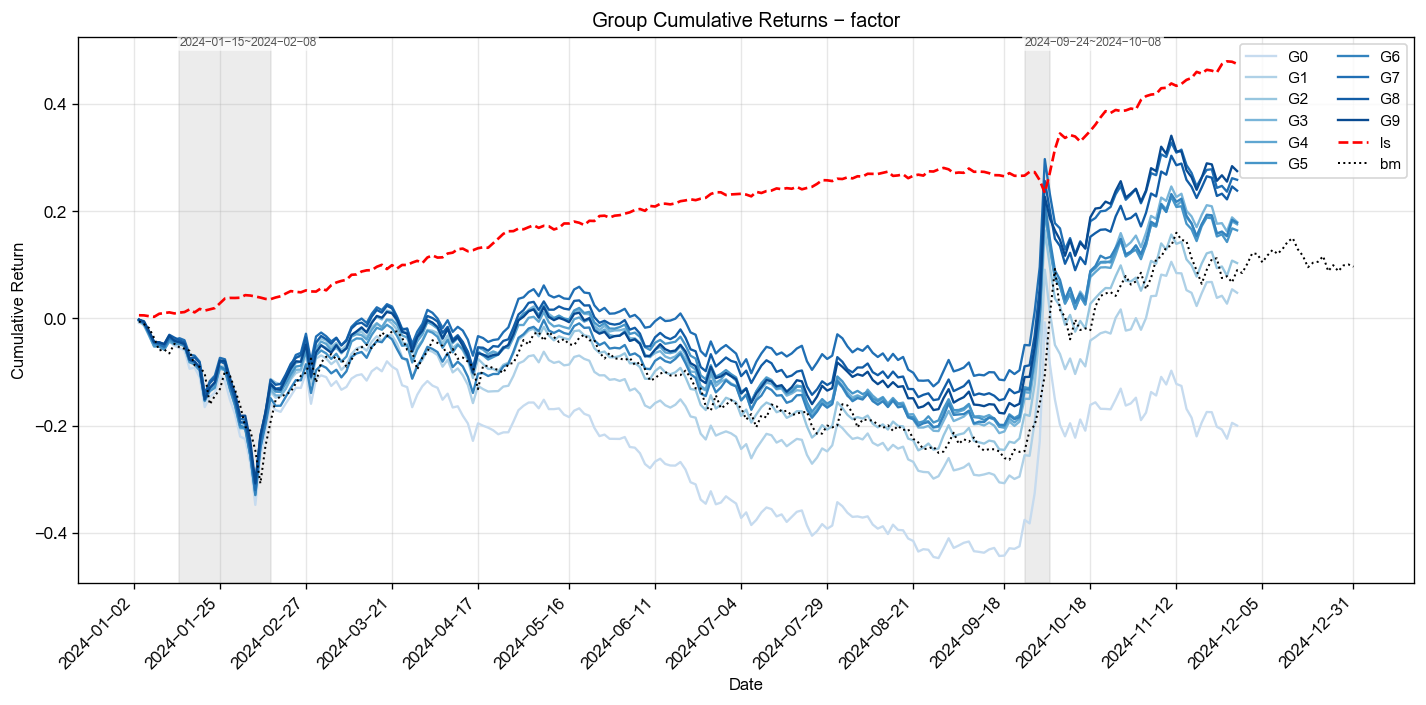
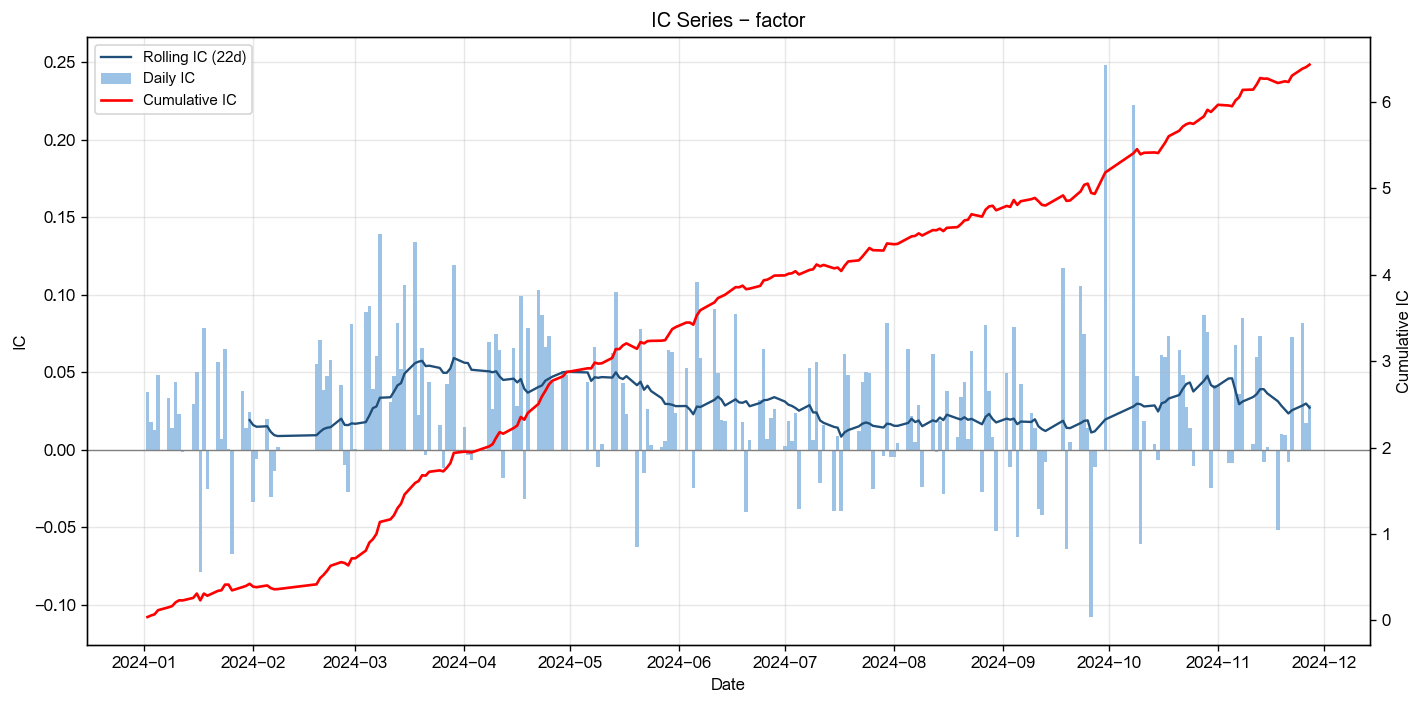
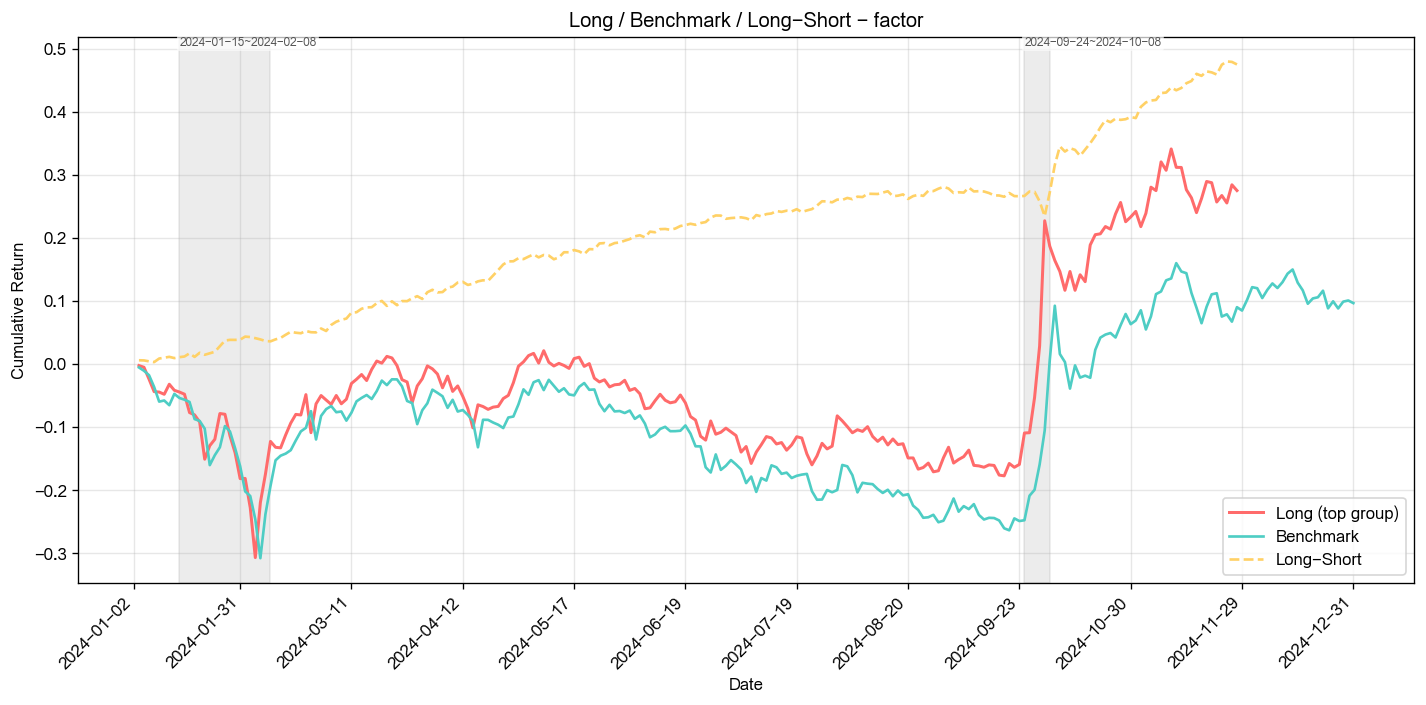
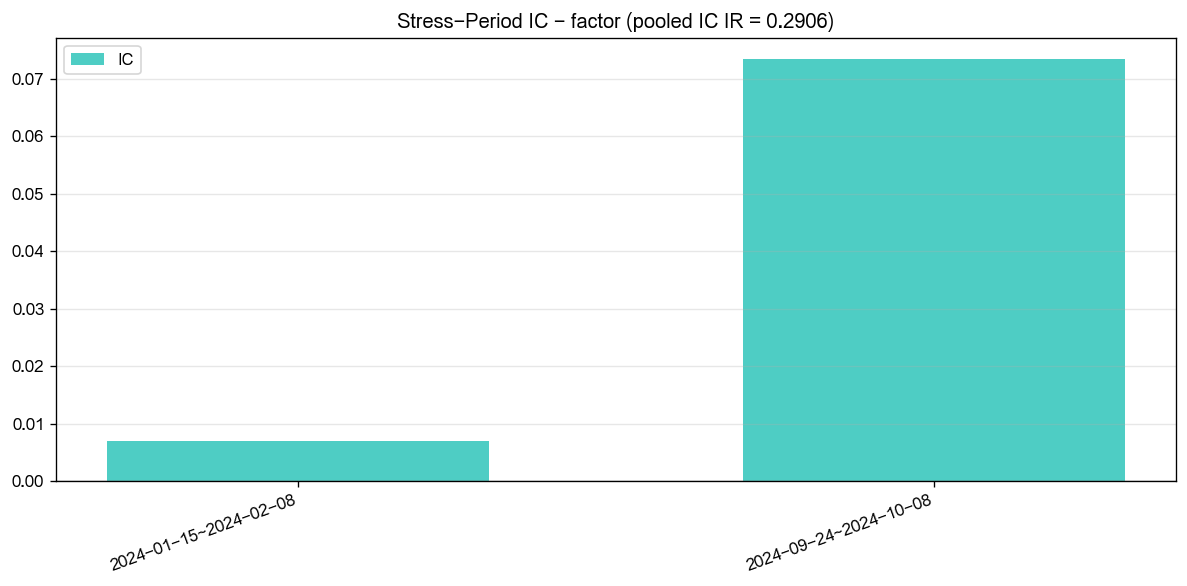
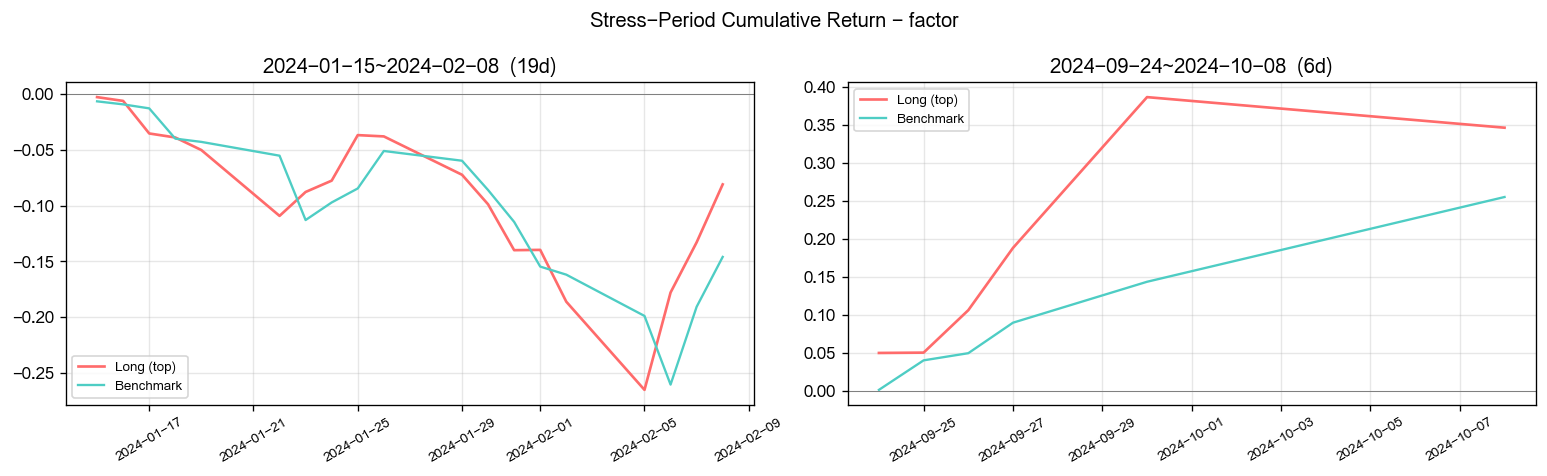

[2026-08-01 13:42:45] [info     ] ========== 因子池回归 ==========
[2026-08-01 13:42:46] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-01 13:42:47] [info     ] 获取收益率数据, 耗时: 1.6115 秒
[2026-08-01 13:42:48] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.9384 秒
[2026-08-01 13:42:48] [info     ] 统计 回归结果, 耗时: 0.1055 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,3.5314,0.0348,0.0098,1.0000
2,rsi_12,1.9785,0.0436,0.0220,1.0000
3,amount,1.7984,0.0172,0.0096,0.9000
4,ps_ttm,1.5266,0.0030,0.0020,0.9000
5,net_profit_rate_ttm,1.5199,0.0036,0.0024,0.9000
6,gross_profit_rate_ttm,1.5080,0.0069,0.0046,0.9000
7,netflow_amount_rate_main,1.4434,0.0094,0.0065,1.0000
8,netflow_amount_main,1.4434,0.0226,0.0157,1.0000
9,cci_14,1.4345,0.0331,0.0231,1.0000
10,pb,1.4333,0.0106,0.0074,0.9000

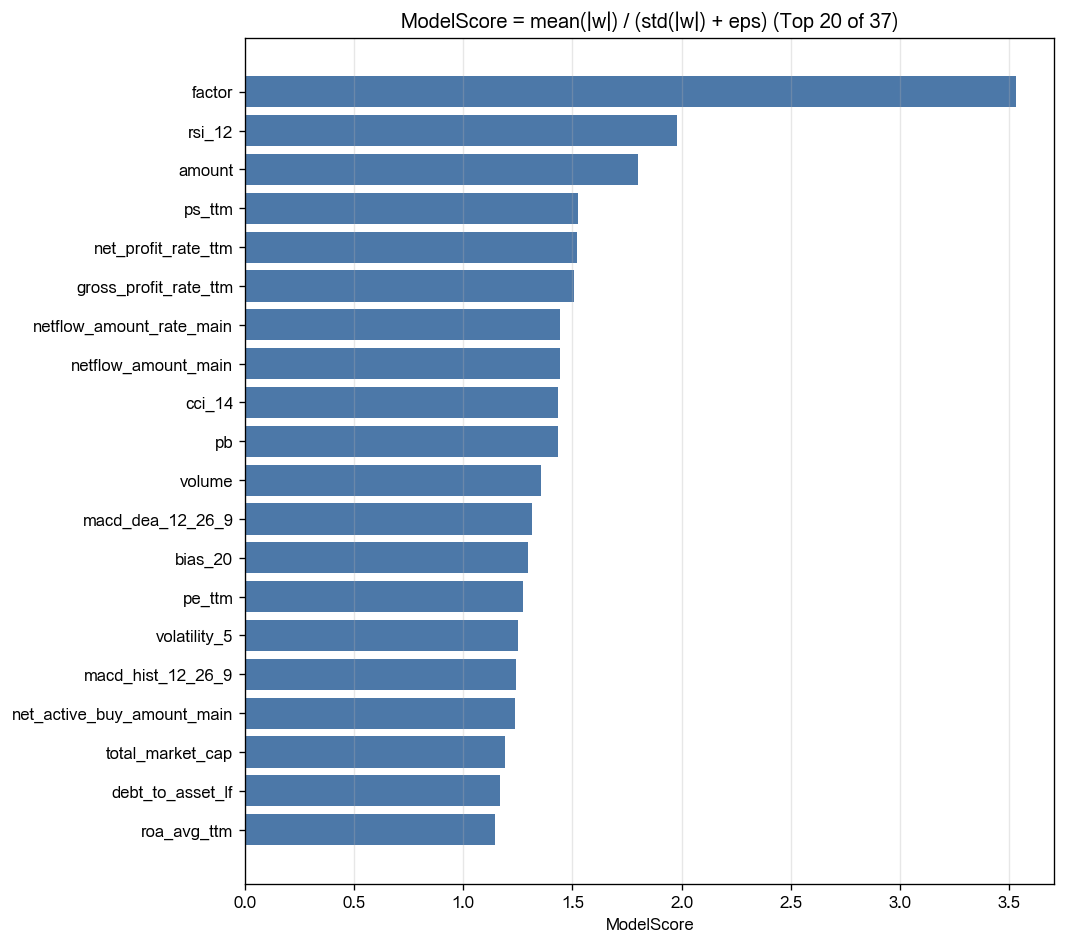
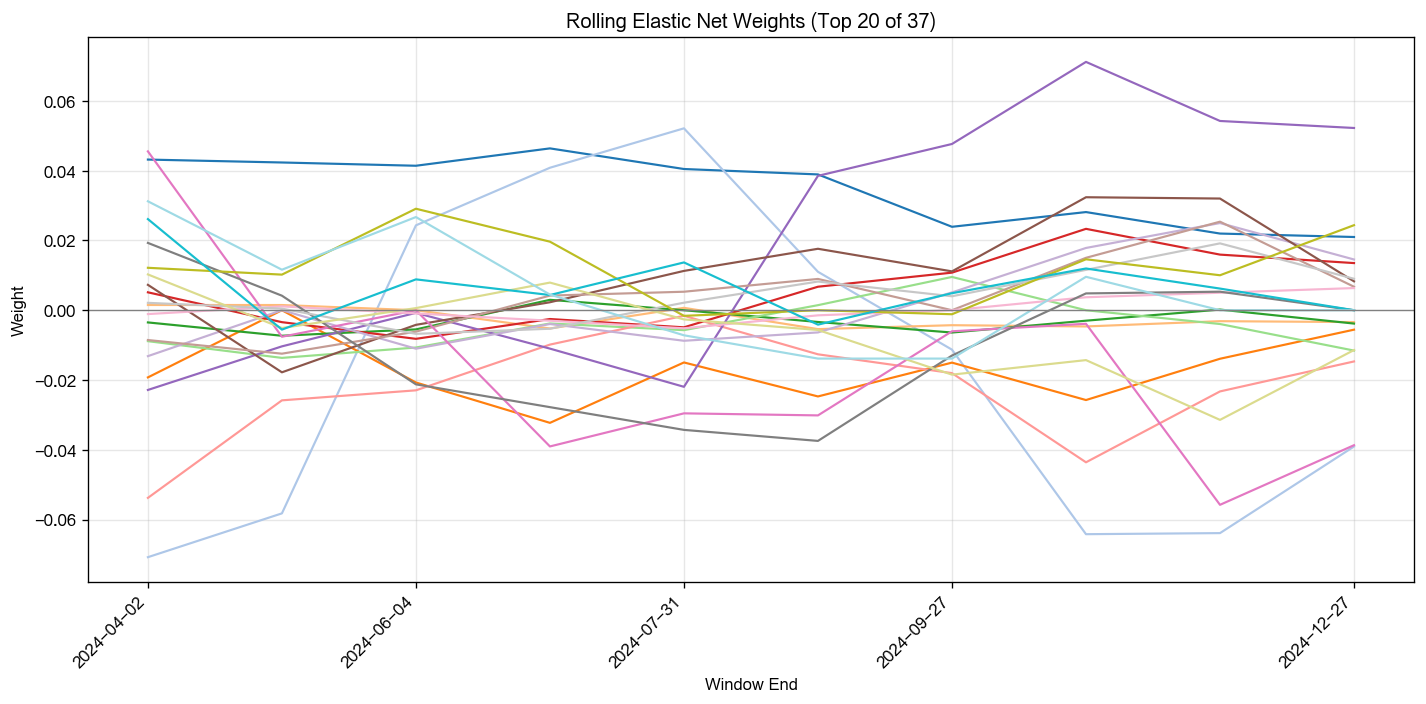
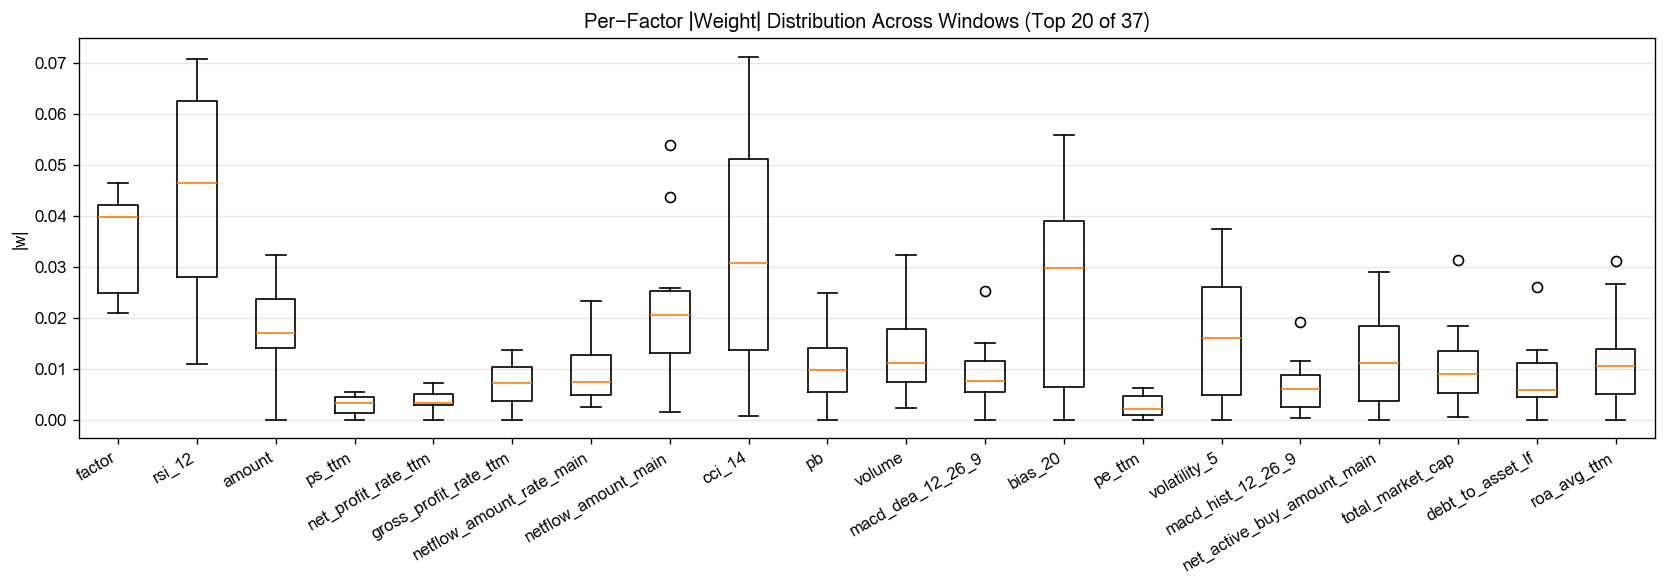
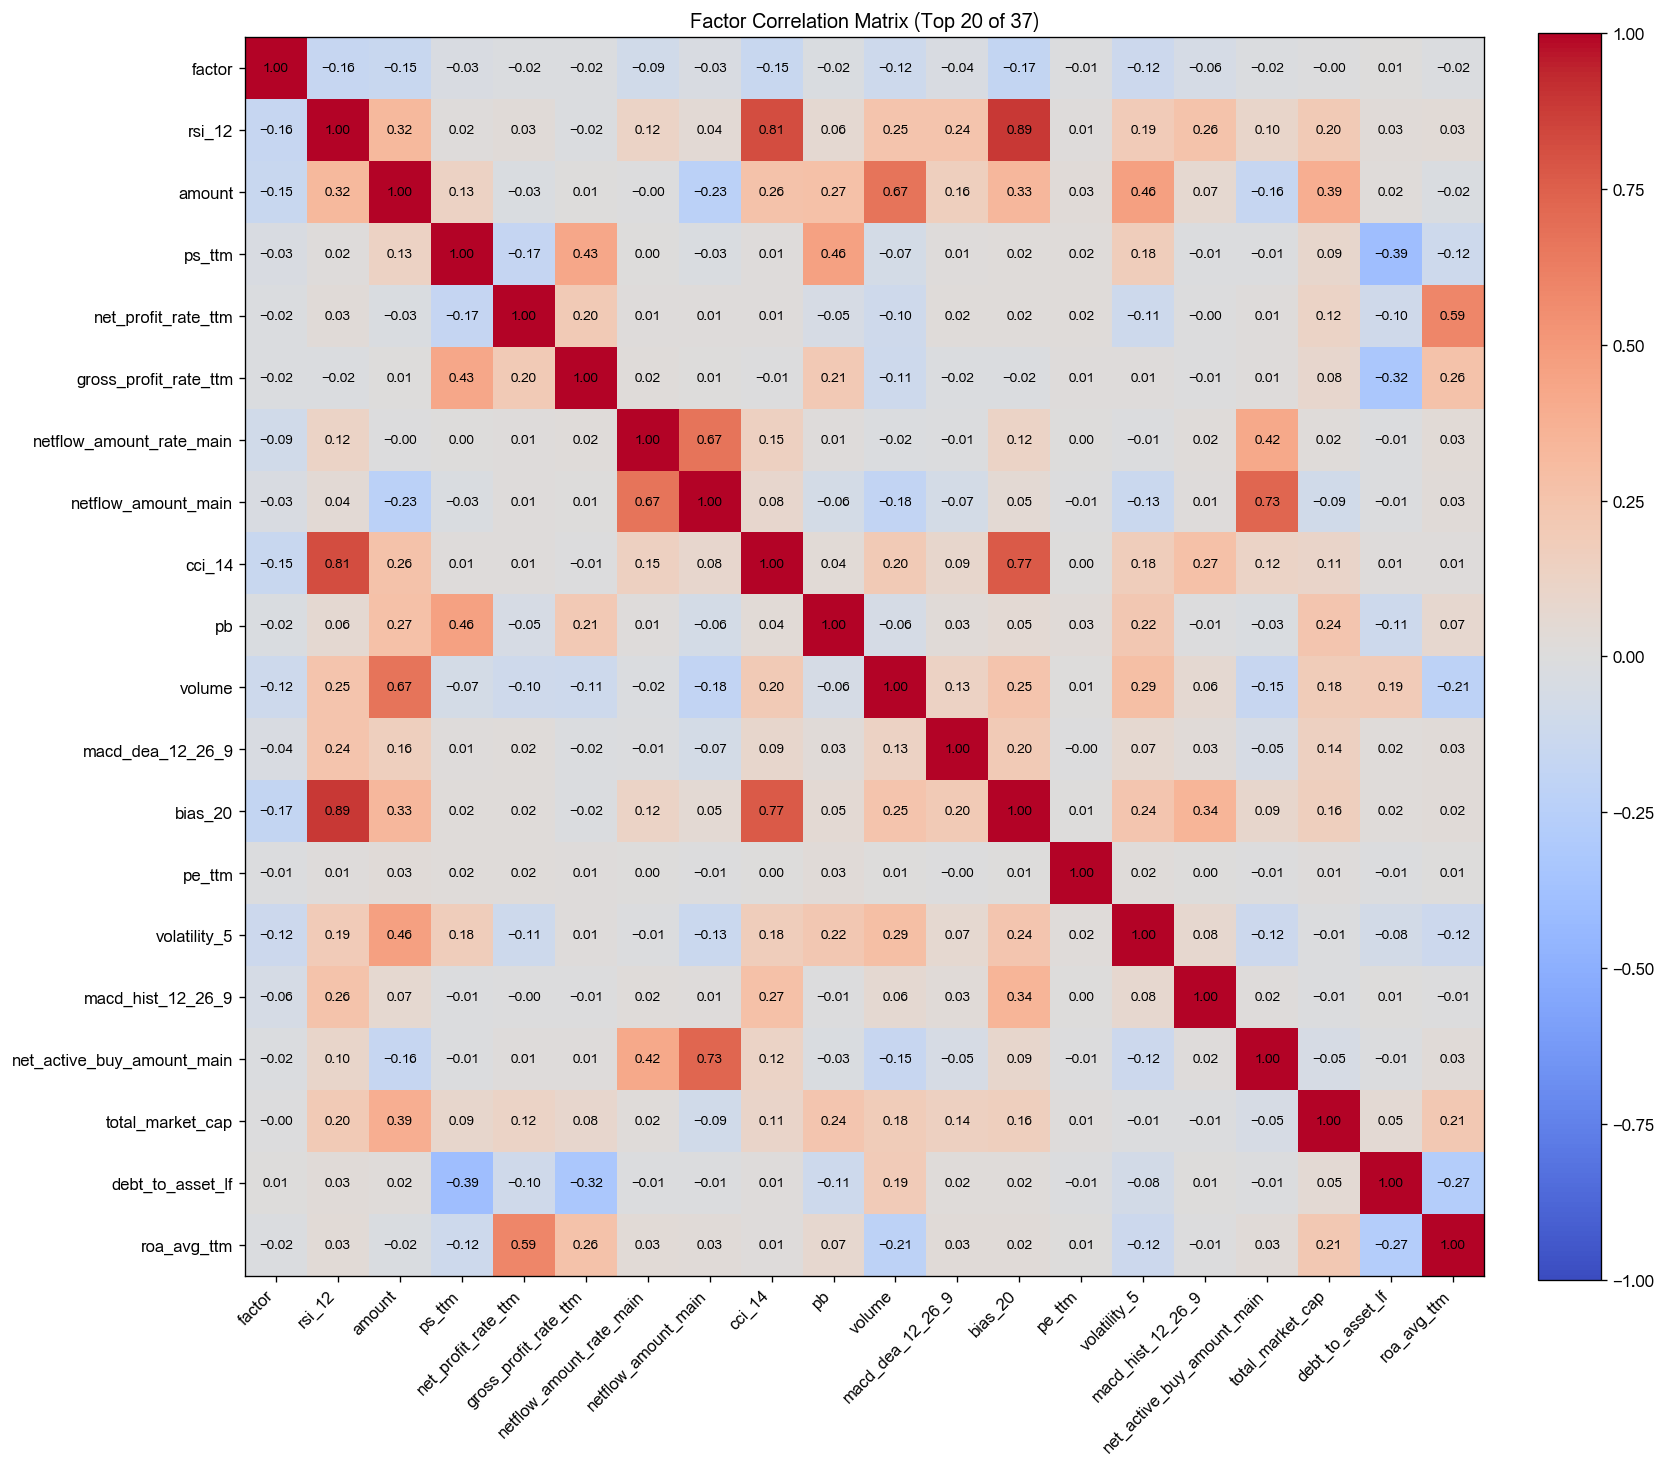

[2026-08-01 13:42:51] [warning  ] 返回的Outputs实例(size=35155049) 大于 64K, 将不会被缓存
[2026-08-01 13:42:51] [info     ] bigalpha_eval.v4 运行完成 [35.856s].


In [1]:
def main(datasources, start_date, end_date):
    """
    BigAlpha 2026 · AI 智能赛道 · 分钟高频遗传算法因子
    特性：无缓存纯实时计算、加入时序算子、验证集早停、集成 hof 因子、固定训练集
    """
    import os, time, gc, random
    from copy import deepcopy
    import numpy as np
    import pandas as pd
    import dai
    import structlog

    logger = structlog.get_logger()
    SEED = 42; random.seed(SEED); np.random.seed(SEED)

    # ==================== 配置区 ====================
    TRAIN_START = '2023-01-01 00:00:00'
    TRAIN_END   = '2023-12-31 23:59:59'
    VAL_START   = '2024-01-01 00:00:00'
    VAL_END     = '2024-12-31 23:59:59'
    
    TRAIN_BAR1M = 'bigalpha_2026_stock_bar1m'

    N_SEG = 16; GENERATIONS = 30; POP_SIZE = 150
    ELITE = 20; PARSIMONY = 0.005; NOVELTY_THRESH = 0.7; PATIENCE = 6; MAX_SIZE = 20
    TS_WINDOWS = [3, 5, 10, 20]

    BARRA = ["SIZE","BETA","MOMENTUM","RESVOL","SIZENL",
             "BTOP","LIQUIDTY","EARNYILD","GROWTH","LEVERAGE"]
    INDUSTRY = ["AGRIFOREST","MINING","CHEM","IRONSTEEL","NONFERMETAL",
                "ELECTRONICS","AUTO","HOUSEAPP","FOODBEVER","TEXTILE",
                "LIGHTINDUS","HEALTH","UTILITIES","TRANSPORTATION","REALESTATE",
                "COMMETRADE","LEISERVICE","BANK","NONBANKFINAN","CONGLOMERATES",
                "CONMAT","BUILDDECO","ELECEQP","MACHIEQUIP","AERODEF",
                "COMPUTER","MEDIA","TELECOM","COAL","PETRO","ENVP","BEAUTY"]
    CHANNELS = ["ch_ret","ch_range","ch_vshare","ch_dshare",
                "ch_obi1","ch_obi5","ch_tamt","ch_spread"]

    # ==================== 基础算子 ====================
    def _sdiv(a, b): return np.where(np.abs(b) > 1e-8, a / b, 0.0)
    def _slog(a):    return np.log1p(np.abs(a)) * np.sign(a)
    def _ssqrt(a):   return np.sqrt(np.abs(a)) * np.sign(a)
    
    BIN_OPS = {"+": np.add, "-": np.subtract, "*": np.multiply,
               "/": _sdiv, "max": np.maximum, "min": np.minimum}
    UNARY = {"abs": np.abs, "neg": np.negative, "sign": np.sign,
             "log": _slog, "sqrt": _ssqrt,
             "sq": lambda a: np.clip(a*a, -1e12, 1e12),
             "inv": lambda a: _sdiv(1.0, a)}

    # ==================== 截面与时序上下文 ====================
    class CSContext:
        def __init__(self, dates):
            codes = pd.factorize(dates, sort=False)[0]
            self.codes = codes
            self.bounds = np.r_[0, np.flatnonzero(np.diff(codes)) + 1]
            self.counts = np.diff(np.r_[self.bounds, len(dates)])
            self.count_of_row = self.counts[codes]
            self.start_of_row = self.bounds[codes]
            
        def zscore(self, v):
            s = np.add.reduceat(v, self.bounds)
            mean = np.repeat(s / self.counts, self.counts)
            sum_sq = np.add.reduceat(v**2, self.bounds)
            var = sum_sq / self.counts - (s / self.counts)**2
            std = np.repeat(np.sqrt(np.maximum(var, 0.0)), self.counts) + 1e-8
            return np.clip((v - mean) / std, -3, 3)
            
        def demean(self, v):
            s = np.add.reduceat(v, self.bounds)
            return v - np.repeat(s / self.counts, self.counts)
            
        def rank(self, v):
            order = np.lexsort((v, self.codes))
            pos = np.empty(len(v)); pos[order] = np.arange(len(v))
            return (pos - self.start_of_row) / np.maximum(self.count_of_row - 1, 1)

    CS_OPS = {"cs_zscore": "zscore", "cs_rank": "rank", "cs_demean": "demean"}

    def _ts_mean(seg, w):
        n = len(seg)
        if n == 0: return seg.copy()
        cs = np.cumsum(np.r_[0.0, seg])
        out = np.empty(n)
        k = min(w, n)
        out[:k] = cs[1:k+1] / np.arange(1, k+1, dtype=np.float32)
        if n > w: out[w:] = (cs[w+1:n+1] - cs[1:n+1-w]) / w
        return out

    def _ts_std(seg, w):
        n = len(seg)
        if n < 2: return np.zeros(n)
        cs  = np.cumsum(np.r_[0.0, seg])
        cs2 = np.cumsum(np.r_[0.0, seg**2])
        out = np.zeros(n)
        for i in range(1, min(w, n)):
            k = i + 1; m = cs[k] / k
            out[i] = np.sqrt(max(cs2[k] / k - m*m, 0.0))
        if n >= w:
            s = cs[w:n+1] - cs[:n+1-w]
            s2 = cs2[w:n+1] - cs2[:n+1-w]
            m = s / w
            out[w-1:] = np.sqrt(np.maximum(s2/w - m*m, 0.0))
        return out

    def _ts_delta(seg, w):
        out = np.zeros(len(seg))
        if len(seg) > w: out[w:] = seg[w:] - seg[:-w]
        return out

    def _ts_max(seg, w):
        n = len(seg)
        if n == 0: return seg.copy()
        out = np.empty(n)
        for i in range(n): out[i] = np.max(seg[max(0, i+1-w):i+1])
        return out

    def _ts_min(seg, w):
        n = len(seg)
        if n == 0: return seg.copy()
        out = np.empty(n)
        for i in range(n): out[i] = np.min(seg[max(0, i+1-w):i+1])
        return out

    def _ts_rank(seg, w):
        n = len(seg)
        if n == 0: return seg.copy()
        out = np.empty(n)
        for i in range(n):
            window = seg[max(0, i+1-w):i+1]
            out[i] = np.sum(window <= seg[i]) / len(window)
        return out

    TS_FUNCS = {'ts_mean': _ts_mean, 'ts_std': _ts_std, 'ts_delta': _ts_delta,
                'ts_max': _ts_max, 'ts_min': _ts_min, 'ts_rank': _ts_rank}
    TS_OP_NAMES = list(TS_FUNCS.keys())

    class TsContext:
        def __init__(self, dates, instruments):
            n = len(dates)
            icodes = pd.factorize(instruments, sort=True)[0]
            dcodes = pd.factorize(dates, sort=True)[0]
            order = np.lexsort((dcodes, icodes))
            self.to_ts = order
            self.from_ts = np.empty(n, dtype=np.intp)
            self.from_ts[order] = np.arange(n)
            si = icodes[order]
            if n > 0:
                chg = np.flatnonzero(si[1:] != si[:-1]) + 1
                self.starts = np.r_[0, chg]
                self.ends   = np.r_[chg, n]
            else:
                self.starts = np.array([], dtype=int)
                self.ends   = np.array([], dtype=int)

        def apply(self, v_orig, op, window):
            v = v_orig[self.to_ts]
            result = np.empty_like(v)
            func = TS_FUNCS[op]
            for a, b in zip(self.starts, self.ends):
                result[a:b] = func(v[a:b], window)
            return result[self.from_ts]

    # ==================== 表达式树与进化机制 ====================
    class Leaf:
        def __init__(self, feat): self.feat = feat
        def __repr__(self): return self.feat
        def size(self): return 1
    class Const:
        def __init__(self, val=None): self.val = val if val is not None else round(random.uniform(-2, 2), 2)
        def __repr__(self): return str(self.val)
        def size(self): return 1
    class Bin:
        def __init__(self, op, l, r): self.op, self.l, self.r = op, l, r
        def __repr__(self): return f"({self.l} {self.op} {self.r})" if self.op in "+-*/" else f"{self.op}({self.l}, {self.r})"
        def size(self): return 1 + self.l.size() + self.r.size()
    class Un:
        def __init__(self, op, c): self.op, self.c = op, c
        def __repr__(self): return f"{self.op}({self.c})"
        def size(self): return 1 + self.c.size()
    class Cs:
        def __init__(self, op, c): self.op, self.c = op, c
        def __repr__(self): return f"{self.op}({self.c})"
        def size(self): return 1 + self.c.size()
    class Ts:
        def __init__(self, op, c, window): self.op, self.c, self.window = op, c, window
        def __repr__(self): return f"{self.op}({self.c},{self.window})"
        def size(self): return 1 + self.c.size()

    def _ev_raw(node, F, idx, cs, ts):
        t = type(node)
        if t is Leaf:  return F[:, idx[node.feat]]
        if t is Const: return np.full(F.shape[0], node.val, dtype=np.float32)
        if t is Bin:   return BIN_OPS[node.op](_ev_raw(node.l, F, idx, cs, ts), _ev_raw(node.r, F, idx, cs, ts))
        if t is Un:    return UNARY[node.op](_ev_raw(node.c, F, idx, cs, ts))
        if t is Cs:    return getattr(cs, CS_OPS[node.op])(_ev_raw(node.c, F, idx, cs, ts))
        if t is Ts:    return ts.apply(_ev_raw(node.c, F, idx, cs, ts), node.op, node.window)
        
    def ev(node, F, idx, cs, ts):
        return np.nan_to_num(_ev_raw(node, F, idx, cs, ts), nan=0.0, posinf=0.0, neginf=0.0)

    def rand_tree(feats, depth=3):
        if depth <= 0 or random.random() < 0.3:
            return Leaf(random.choice(feats)) if random.random() < 0.92 else Const()
        r = random.random()
        if r < 0.25:
            return Bin(random.choice(list(BIN_OPS)), rand_tree(feats, depth-1), rand_tree(feats, depth-1))
        elif r < 0.45:
            return Un(random.choice(list(UNARY)), rand_tree(feats, depth-1))
        elif r < 0.70:
            return Cs(random.choice(list(CS_OPS)), rand_tree(feats, depth-1))
        else:
            return Ts(random.choice(TS_OP_NAMES), rand_tree(feats, depth-1), random.choice(TS_WINDOWS))

    def all_slots(node):
        slots = [(None, None)]
        if type(node) is Bin:
            slots += [(node,"l")] + all_slots(node.l)
            slots += [(node,"r")] + all_slots(node.r)
        elif type(node) in (Un, Cs, Ts):
            slots += [(node,"c")] + all_slots(node.c)
        return slots

    def mutate(node, feats):
        node = deepcopy(node)
        pa, attr = random.choice(all_slots(node))
        sub = rand_tree(feats, depth=2)
        if pa is None: return sub
        setattr(pa, attr, sub)
        return node if node.size() <= MAX_SIZE else rand_tree(feats, 3)

    def crossover(a, b, feats):
        a, b = deepcopy(a), deepcopy(b)
        pa, attr = random.choice(all_slots(a))
        sb_pa, sb_attr = random.choice(all_slots(b))
        sub = b if sb_pa is None else getattr(sb_pa, sb_attr)
        if pa is None: return sub if sub.size() <= MAX_SIZE else rand_tree(feats, 3)
        setattr(pa, attr, sub)
        return a if a.size() <= MAX_SIZE else rand_tree(feats, 3)

    # ==================== 适应度上下文 ====================
    class FitCtx:
        def __init__(self, panel, feats):
            self.F = np.ascontiguousarray(panel[feats].to_numpy(np.float32))
            self.colidx = {c: i for i, c in enumerate(feats)}
            
            dates = panel['date'].to_numpy()
            instruments = panel['instrument'].to_numpy()
            self.cs = CSContext(dates)
            self.ts = TsContext(dates, instruments)
            
            self.day_slices = [(self.cs.bounds[i], self.cs.bounds[i] + self.cs.counts[i])
                               for i in range(len(self.cs.counts))]

            risk_cols = [c for c in BARRA + INDUSTRY if c in panel.columns]
            R = panel[risk_cols].fillna(0).to_numpy(np.float32) if risk_cols else None
            y = panel['y_neutral'].to_numpy(np.float32)
            
            self.Q, self.yres, self.ynorm, self.keep = [], [], [], []
            for (a, b) in self.day_slices:
                if b - a < 50:
                    self.Q.append(None); self.yres.append(None)
                    self.ynorm.append(None); self.keep.append(False); continue
                X = np.c_[np.ones(b-a), R[a:b]] if R is not None else np.ones((b-a, 1))
                q, _ = np.linalg.qr(X)
                yr = y[a:b].copy(); yr = yr - q @ (q.T @ yr); yr = yr - yr.mean()
                self.Q.append(q); self.yres.append(yr)
                self.ynorm.append(np.linalg.norm(yr) + 1e-12); self.keep.append(True)

        def score(self, node):
            try:
                fac = ev(node, self.F, self.colidx, self.cs, self.ts)
            except Exception:
                return -1.0, 0.0
            if fac.std() < 1e-9: return -1.0, 0.0
            ics = []
            for k, (a, b) in enumerate(self.day_slices):
                if not self.keep[k]: continue
                f = fac[a:b]
                v = self.Q[k].T @ f
                n2 = np.sum(f**2) - np.sum(v**2)
                if n2 < 1e-18: continue
                ics.append((f @ self.yres[k]) / (np.sqrt(n2) * self.ynorm[k]))
            if len(ics) < 20: return -1.0, 0.0
            return float(np.mean(ics)), float(np.std(ics))

        def factor_values(self, node):
            return self.cs.zscore(ev(node, self.F, self.colidx, self.cs, self.ts))

    # ==================== GA 主循环 ====================
    def run_ga(fit, val_fit, feats):
        pop = [rand_tree(feats, 3) for _ in range(POP_SIZE)]
        hof = []; best_ever = -1e9; stall = 0
        
        for gen in range(GENERATIONS):
            t0 = time.time()
            
            # 训练集评分
            ranked = []
            for ind in pop:
                m, s = fit.score(ind)
                ir = m / (s + 1e-8) if s > 0 else m * 5
                ranked.append((ir - PARSIMONY * ind.size(), ir, m, ind))
            ranked.sort(key=lambda x: -x[0])
            _, ir_best, ic_best, best_ind = ranked[0]
            
            # 验证集筛 HoF
            for _, _, ic_i, ind in ranked[:8]:
                if ic_i <= 0: continue
                v_ic, v_std = val_fit.score(ind)
                if v_ic <= 0: continue
                v_ir = v_ic / (v_std + 1e-8) if v_std > 0 else v_ic * 5
                vals = val_fit.factor_values(ind)
                novel = all(abs(np.corrcoef(vals, hv)[0,1]) <= NOVELTY_THRESH for *_, hv in hof)
                if novel:
                    hof.append((v_ir, v_ic, deepcopy(ind), vals))
                    
            hof.sort(key=lambda x: -x[0]); hof = hof[:10]
            best_val_ic = hof[0][1] if hof else -1.0
            
            logger.info(f"gen{gen:03d} train_IC={ic_best:+.4f} val_IC={best_val_ic:+.4f} "
                        f"size={best_ind.size()} {time.time()-t0:.1f}s {repr(best_ind)[:60]}")

            # 早停控制
            ir_adj = ranked[0][0]
            if ir_adj > best_ever + 1e-4:
                best_ever, stall = ir_adj, 0
            else:
                stall += 1
                if stall >= PATIENCE:
                    logger.info(f"连续{PATIENCE}代无改进，早停"); break

            elites = [deepcopy(r[3]) for r in ranked[:ELITE]]
            pool = [r[3] for r in ranked[:POP_SIZE//2]]
            newpop = list(elites)
            while len(newpop) < POP_SIZE:
                r = random.random()
                if r < 0.45:   newpop.append(crossover(random.choice(elites), random.choice(pool), feats))
                elif r < 0.85: newpop.append(mutate(random.choice(elites), feats))
                else:          newpop.append(rand_tree(feats, 3))
            pop = newpop
            
        if not hof:
            raise RuntimeError("GA 未找到有效公式")
        return hof

    # ==================== 数据构建 SQL ====================
    SQL_SEG = """
    WITH b AS (
        SELECT CAST(date AS DATE) AS dt, instrument, date AS ts,
               CASE WHEN HOUR(date) < 12
                    THEN (HOUR(date)*60 + MINUTE(date) - 571)
                    ELSE (HOUR(date)*60 + MINUTE(date) - 781 + 120)
               END AS min_idx,
               high, low, close, volume, amount, deal_number, adjust_factor,
               bid_volume1, ask_volume1,
               bid_volume1+bid_volume2+bid_volume3+bid_volume4+bid_volume5 AS bv5,
               ask_volume1+ask_volume2+ask_volume3+ask_volume4+ask_volume5 AS av5,
               bid_price1, ask_price1
        FROM {tbl}
        WHERE volume > 0 AND bid_price1 > 0 AND ask_price1 > 0 AND ask_price1 >= bid_price1
    ),
    r AS (
        SELECT *, LEAST(GREATEST(min_idx/15, 0), 15)::INT AS seg,
            close / NULLIF(LAG(close) OVER (PARTITION BY instrument, dt ORDER BY ts), 0) - 1 AS ret
        FROM b
    ),
    day_tot AS (
        SELECT dt, instrument, SUM(volume) AS vol_day,
               SUM(GREATEST(deal_number, 0)) AS deal_day
        FROM r GROUP BY dt, instrument
    )
    SELECT r.dt AS date, r.instrument, r.seg,
        COALESCE(SUM(r.ret), 0)                                                    AS ch_ret,
        COALESCE((MAX(r.high)-MIN(r.low))/NULLIF(AVG(r.close),0), 0)               AS ch_range,
        COALESCE(SUM(r.volume)/NULLIF(d.vol_day,0), 0)                             AS ch_vshare,
        COALESCE(SUM(GREATEST(r.deal_number,0))/NULLIF(d.deal_day,0), 0)           AS ch_dshare,
        COALESCE(AVG((r.bid_volume1-r.ask_volume1)
                     /NULLIF(r.bid_volume1+r.ask_volume1,0)), 0)                   AS ch_obi1,
        COALESCE(AVG((r.bv5-r.av5)/NULLIF(r.bv5+r.av5,0)), 0)                     AS ch_obi5,
        COALESCE(LN(1+GREATEST(AVG(GREATEST(r.amount,0)
                     /NULLIF(GREATEST(r.deal_number,0),0)),0)), 0)                 AS ch_tamt,
        COALESCE(AVG((r.ask_price1-r.bid_price1)
                     /NULLIF((r.ask_price1+r.bid_price1)/2,0)), 0)                 AS ch_spread,
        ARG_MAX(r.close*r.adjust_factor, r.ts) AS adj_close_seg, COUNT(*) AS n_bars
    FROM r JOIN day_tot d USING (dt, instrument)
    GROUP BY r.dt, r.instrument, r.seg, d.vol_day, d.deal_day
    """

    def build_seg_wide(bar1m_table, sd, ed, need_label):
        sd_s, ed_s = str(pd.to_datetime(sd)), str(pd.to_datetime(ed))
        t0 = time.time()
        
        # 直接拉取，无缓存
        seg = dai.query(SQL_SEG.format(tbl=bar1m_table), filters={'date': [sd_s, ed_s]}).df()
        
        # Object 转 float32 防止后续计算报错
        for c in CHANNELS:
            if c in seg.columns:
                seg[c] = pd.to_numeric(seg[c], errors='coerce').astype(np.float32)
                
        seg['date'] = pd.to_datetime(seg['date'])
        day_bars = seg.groupby(['date','instrument'])['n_bars'].sum().reset_index(name='dn')
        seg = seg.merge(day_bars, on=['date','instrument'])
        seg = seg[seg['dn'] >= 100].drop(columns=['n_bars','dn'])

        seg['seg'] = seg['seg'].clip(0, 15).astype(int)
        keys = seg[['date','instrument']].drop_duplicates().reset_index(drop=True)
        keys['kid'] = np.arange(len(keys))
        m = seg.merge(keys, on=['date','instrument'])
        
        X = np.zeros((len(keys), N_SEG, len(CHANNELS)), dtype=np.float32)
        X[m['kid'].to_numpy(), m['seg'].to_numpy()] = m[CHANNELS].to_numpy(np.float32)
        wide = keys[['date','instrument']].copy()
        
        for ci, ch in enumerate(CHANNELS):
            for s in range(N_SEG):
                wide[f"s{s}_{ch.replace('ch_','')}"] = X[:, s, ci]

        eod = m[m['seg']==15][['date','instrument','adj_close_seg']].rename(columns={'adj_close_seg': 'adj_close'})
        fb = m.groupby(['date','instrument'])['adj_close_seg'].max().reset_index(name='adj_fb')
        wide = wide.merge(eod, on=['date','instrument'], how='left') \
                   .merge(fb, on=['date','instrument'], how='left')
        wide['adj_close'] = wide['adj_close'].fillna(wide['adj_fb'])
        wide = wide.drop(columns=['adj_fb'])
        
        # 清理内存
        del seg, m, X, keys, eod, fb; gc.collect()

        if need_label:
            wide = wide.sort_values(['instrument','date'])
            wide['fwd_ret'] = (wide.groupby('instrument')['adj_close'].shift(-1) / wide['adj_close'] - 1)
            
        wide = wide.drop(columns=['adj_close'])
        atom_cols = [c for c in wide.columns if c not in ('date','instrument','fwd_ret')]
        logger.info(f"宽表完成", shape=wide.shape, atoms=len(atom_cols), elapsed=round(time.time()-t0,1))
        return wide, atom_cols

    def load_universe(sd, ed):
        stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                        filters={'date': [str(pd.to_datetime(sd)), str(pd.to_datetime(ed))]}).df()
        stk['date'] = pd.to_datetime(stk['date'])
        stk['instrument'] = stk['instrument'].astype(str)
        return stk

    def prep_panel(panel, sd, ed):
        """通用中性化和合池面板，即插即用且即时清理"""
        stk_pool = load_universe(sd, ed)
        panel['instrument'] = panel['instrument'].astype(str)
        panel = panel.merge(stk_pool, on=['date','instrument'], how='inner')
        del stk_pool; gc.collect()
        
        try:
            exp = dai.query(
                f"SELECT date, instrument, {','.join(BARRA+INDUSTRY)} FROM bigalpha_2026_exposure",
                filters={'date': [str(pd.to_datetime(sd)), str(pd.to_datetime(ed))]}).df()
            exp['date'] = pd.to_datetime(exp['date'])
            panel = panel.merge(exp, on=['date','instrument'], how='left')
            del exp; gc.collect()
            
            def _neut(g):
                y = g['fwd_ret'].to_numpy(); v = ~np.isnan(y)
                if v.sum() < 50: return pd.Series(np.nan, index=g.index)
                X = np.c_[np.ones(v.sum()), g.loc[v, BARRA+INDUSTRY].fillna(0).to_numpy()]
                b, *_ = np.linalg.lstsq(X, y[v], rcond=None)
                out = np.full(len(y), np.nan); out[v] = y[v] - X @ b
                return pd.Series(out, index=g.index)
                
            panel['y_neutral'] = panel.groupby('date', group_keys=False).apply(_neut)
            panel = panel.drop(columns=[c for c in BARRA+INDUSTRY if c in panel.columns])
        except Exception as e:
            logger.warning(f"exposure 不可用: {e}，跳过标签中性化")
            panel['y_neutral'] = panel['fwd_ret']
            
        return panel

    def prepare_dataset(sd, ed, atom_cols=None):
        wide, cols = build_seg_wide(TRAIN_BAR1M, sd, ed, need_label=True)
        if atom_cols is None: atom_cols = cols
        
        panel = prep_panel(wide, sd, ed)
        del wide; gc.collect() # 严控内存
        
        df = panel[panel['y_neutral'].notna()].sort_values('date').reset_index(drop=True)
        del panel; gc.collect()
        
        # 截面标准化
        g = df.groupby('date')[atom_cols]
        df[atom_cols] = ((df[atom_cols] - g.transform('mean'))
                         / (g.transform('std') + 1e-8)).clip(-3, 3).fillna(0.0)
        return df, atom_cols

    # ==================== Train / Predict ====================
    def train():
        logger.info("== 1. 构建训练集 ==")
        tr, atom_cols = prepare_dataset(TRAIN_START, TRAIN_END)
        logger.info(f"训练样本就绪: {len(tr)} 行 / {tr['date'].nunique()} 天")
        
        logger.info("== 2. 构建验证集 ==")
        vl, _ = prepare_dataset(VAL_START, VAL_END, atom_cols)
        logger.info(f"验证样本就绪: {len(vl)} 行 / {vl['date'].nunique()} 天")

        logger.info("== 3. 遗传算法进化 ==")
        t0 = time.time()
        fit = FitCtx(tr, atom_cols)
        del tr; gc.collect() # 脱手即删
        
        val_fit = FitCtx(vl, atom_cols)
        del vl; gc.collect()

        hof = run_ga(fit, val_fit, atom_cols)
        logger.info(f"GA 完毕，用时 {(time.time()-t0)/60:.1f} 分钟")

        for i, (ir, ic, node, _) in enumerate(hof):
            logger.info(f"hof#{i+1} val_IC={ic:+.4f} IR={ir:+.2f} size={node.size()} {repr(node)[:80]}")

        del fit, val_fit; gc.collect()
        return hof, atom_cols

    def predict(hof, atom_cols):
        logger.info("== Predict (测试集推断) ==")
        # 提取时序算子所需的额外历史天数
        buf = (pd.to_datetime(start_date) - pd.Timedelta(days=max(TS_WINDOWS) * 2 + 5)).strftime('%Y-%m-%d %H:%M:%S')
        
        panel, _ = build_seg_wide(datasources['bar1m'], buf, end_date, need_label=False)
        panel = panel.sort_values(['date','instrument']).reset_index(drop=True)

        g = panel.groupby('date')[atom_cols]
        panel[atom_cols] = ((panel[atom_cols] - g.transform('mean'))
                            / (g.transform('std') + 1e-8)).clip(-3, 3).fillna(0.0)

        F   = np.ascontiguousarray(panel[atom_cols].to_numpy(np.float32))
        idx = {c: i for i, c in enumerate(atom_cols)}
        cs  = CSContext(panel['date'].to_numpy())
        ts  = TsContext(panel['date'].to_numpy(), panel['instrument'].to_numpy())

        # IC 加权集成 hof 因子
        factors, weights = [], []
        for ir, ic, node, _ in hof:
            fv = cs.zscore(ev(node, F, idx, cs, ts))
            factors.append(fv)
            weights.append(max(ic, 0.0))
            logger.info(f"  集成: {repr(node)[:60]} val_IC={ic:+.4f}")

        w_sum = sum(weights)
        if w_sum > 0:
            weights = [w / w_sum for w in weights]
        else:
            weights = [1.0 / len(hof)] * len(hof)

        panel['factor'] = sum(w * fv for w, fv in zip(weights, factors))
        del F, factors; gc.collect()

        # 裁剪到目标区间并合池
        panel = panel[panel['date'] >= pd.to_datetime(start_date)]
        stk = load_universe(start_date, end_date)
        panel['instrument'] = panel['instrument'].astype(str)
        
        result = (panel[['date','instrument','factor']]
                  .merge(stk, on=['date','instrument'], how='inner'))
        result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
        result = result.dropna(subset=['factor']).reset_index(drop=True)
        
        logger.info("预测完成", rows=len(result), 集成因子数=len(hof))
        return result[['date','instrument','factor']]

    # ==================== 执行入口 ====================
    hof, atom_cols = train()
    result = predict(hof, atom_cols)
    return result

if __name__ == '__main__':
    from bigmodule import M
    import dai, structlog
    logger = structlog.get_logger()
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m', 'financial': 'bigalpha_2026_financial'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'
    factor_data = main(datasources, start_date, end_date)
    factor_pool = dai.query("SELECT * FROM bigalpha_2026_factorlib",
                             filters={'date': [start_date, end_date]}).df()
    result = M.bigalpha_eval._latest(factor_data=factor_data, factor_pool=factor_pool,
                                      process_pools=False, show=True)